<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="cognitiveclass.ai logo">
</center>

# Hands-on Lab: API Examples
## Random User and Fruityvice API Examples


Estimated time needed: **30** minutes

## Objectives

After completing this lab you will be able to:

*   Load and use RandomUser API, using `RandomUser()` Python library
*   Load and use Fruityvice API, using `requests` Python library
*   Load and use Open-Joke-API, using `requests` Python library



The purpose of this notebook is to provide more examples on how to use simple APIs. As you have already learned from previous videos and notebooks, API stands for Application Programming Interface and is a software intermediary that allows two applications to talk to each other. 

The advantages of using APIs:
 *   **Automation**. Less human effort is required and workflows can be easily updated to become faster and more      
     productive.
 *   **Efficiency**. It allows to use the capabilities of one of the already developed APIs than to try to 
     independently implement some functionality from scratch.
 
The disadvantage of using APIs:
 *   **Security**. If the API is poorly integrated, it means it will be vulnerable to attacks, resulting in data breeches or losses having financial or reputation implications.

One of the applications we will use in this notebook is Random User Generator. RandomUser is an open-source, free API providing developers with randomly generated users to be used as placeholders for testing purposes. This makes the tool similar to Lorem Ipsum, but is a placeholder for people instead of text. The API can return multiple results, as well as specify generated user details such as gender, email, image, username, address, title, first and last name, and more. More information on [RandomUser](https://randomuser.me/documentation#intro) can be found here.

Another example of simple API we will use in this notebook is Fruityvice application. The Fruityvice API web service which provides data for all kinds of fruit! You can use Fruityvice to find out interesting information about fruit and educate yourself. The web service is completely free to use and contribute to.


## Example 1: RandomUser API
Bellow are Get Methods parameters that we can generate. For more information on the parameters, please visit this [documentation](https://randomuser.me/documentation) page.


## **Get Methods**

- get_cell()
- get_city()
- get_dob()
- get_email()
- get_first_name()
- get_full_name()
- get_gender()
- get_id()
- get_id_number()
- get_id_type()
- get_info()
- get_last_name()
- get_login_md5()
- get_login_salt()
- get_login_sha1()
- get_login_sha256()
- get_nat()
- get_password()
- get_phone()
- get_picture()
- get_postcode()
- get_registered()
- get_state()
- get_street()
- get_username()
- get_zipcode()


To start using the API you can install the `randomuser` library running the `pip install` command.


In [3]:
#imma leave this commented since im running the notebook on my local machine and use the terminal to install libraries :)
#!pip install randomuser

Then, we will load the necessary libraries.


In [4]:
from randomuser import RandomUser
import pandas as pd

First, we will create a random user object, r.


In [5]:
r = RandomUser()

Then, using `generate_users()` function, we get a list of random 10 users.


In [6]:
some_list = r.generate_users(10)

In [7]:
some_list

The **"Get Methods"** functions mentioned at the beginning of this notebook, can generate the required parameters to construct a dataset. For example, to get full name, we call `get_full_name()` function.


In [8]:
name = r.get_full_name()

Let's say we only need 10 users with full names and their email addresses. We can write a "for-loop" to print these 10 users.


In [9]:
for user in some_list:
    print (user.get_full_name()," ",user.get_email())

Dejan Brunet   dejan.brunet@example.com
Vanderléia Santos   vanderleia.santos@example.com
Alena Brun   alena.brun@example.com
Emma Kallevik   emma.kallevik@example.com
Juliette Williams   juliette.williams@example.com
Camille Martinez   camille.martinez@example.com
Paige Cooper   paige.cooper@example.com
Suman Modderkolk   suman.modderkolk@example.com
Katie Taylor   katie.taylor@example.com
Iiris Kivisto   iiris.kivisto@example.com


## Exercise 1
In this Exercise, generate photos of the random 10 users.


### Scratch Work.

---

There is a `get_picture()` method. I'll check what it returns

In [10]:
## Write your code here
photo1 = some_list[0].get_picture()
photo1

'https://randomuser.me/api/portraits/men/63.jpg'

It returned a URL. So, to download the pictures, I'll make a get request.

In [11]:
import requests

photo1_r = requests.get(photo1)
photo1_r.headers

/Users/jelo/anaconda3/envs/IBM-DS/lib/python3.14/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


{'Date': 'Sat, 09 May 2026 08:27:56 GMT', 'Content-Type': 'image/jpeg', 'Content-Length': '25892', 'Connection': 'keep-alive', 'Server': 'cloudflare', 'Last-Modified': 'Tue, 05 Jul 2022 00:27:53 GMT', 'Nel': '{"report_to":"cf-nel","success_fraction":0.0,"max_age":604800}', 'etag': '"62c38589-6524"', 'expires': 'Tue, 19 May 2026 07:41:29 GMT', 'Cache-Control': 'public, max-age=2592000', 'Accept-Ranges': 'bytes', 'Age': '1730786', 'cf-cache-status': 'HIT', 'Report-To': '{"group":"cf-nel","max_age":604800,"endpoints":[{"url":"https://a.nel.cloudflare.com/report/v4?s=vcnTWyQqtVxUkytO6amy7zeGrzHLl7mR79bNqjxc5r2qNr%2BVWUF7HWA7MPiUw8gROvPsMpex%2FXfMobpjo%2FBWJSMEbduzaMZZ1qS1A%2Fuc3cTASmPfL7QnIyDeDUM%2BalEI"}]}', 'CF-RAY': '9f8f53eb186cef82-MNL', 'alt-svc': 'h3=":443"; ma=86400'}

As seen from the response header, the content type is 'image/jpeg'. However, this response contains the image in bytes. To convert it as an actual image, we can write its contents to an image file object. So, first define the file path and name using `os`, and then write the contents using `open`

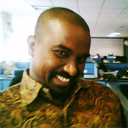

In [12]:
import os
from PIL import Image
from IPython.display import IFrame
from IPython.display import display

photo1_path = os.path.join(os.getcwd(),'assets/photo1.jpeg') # define file path and file name; in this case, I saved it as photo1.jpeg in the current working directory

# write contents to image file
with open(photo1_path,'wb') as f:
    f.write(photo1_r.content)

# view the image to check if it worked:
display(Image.open(photo1_path))

Wahoow! it worked! :) now to do the same thing for the rest of the 10 users.

---

### Solution.

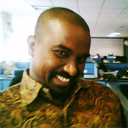

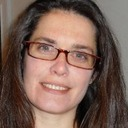

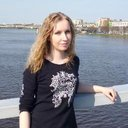

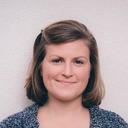

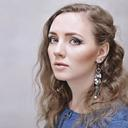

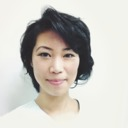

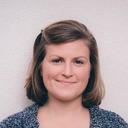

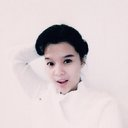

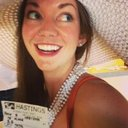

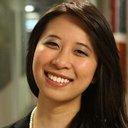

In [13]:
# Download the images
imgPaths=[]
for index, userImg in enumerate([user.get_picture() for user in some_list],start=1):
    imgPaths.append(os.path.join(os.getcwd(),f'assets/img{index}.jpeg'))
    with open(imgPaths[index-1],'wb') as imFile:
        imFile.write(requests.get(userImg).content)

# Display images
imgDisplay = [display(Image.open(img)) for img in imgPaths]
imgDisplay[0]

<details><summary>Click here for the solution</summary>

```python
for user in some_list:
    print (user.get_picture())
```

</details>


To generate a table with information about the users, we can write a function containing all desirable parameters. For example, name, gender, city, etc. The parameters will depend on the requirements of the test to be performed. We call the Get Methods, listed at the beginning of this notebook. Then, we return pandas dataframe with the users.


In [14]:
def get_users():
    users =[]
     
    for user in RandomUser.generate_users(10):
        users.append({"Name":user.get_full_name(),"Gender":user.get_gender(),"City":user.get_city(),"State":user.get_state(),"Email":user.get_email(), "DOB":user.get_dob(),"Picture":user.get_picture()})
      
    return pd.DataFrame(users)     

In [15]:
get_users()

,Name,Gender,City,State,Email,DOB,Picture
0,Maddison Brooks,female,Tipperary,Cavan,maddison.brooks@example.com,1975-12-27T10:28:09.678Z,https://randomuser.me/api/portraits/women/21.jpg
1,Maxwell Pearson,male,Maynooth,Laois,maxwell.pearson@example.com,1963-12-23T06:19:07.305Z,https://randomuser.me/api/portraits/men/49.jpg
2,Darrell Wheeler,male,Lisburn,Dumfries and Galloway,darrell.wheeler@example.com,1964-11-28T06:48:53.314Z,https://randomuser.me/api/portraits/men/99.jpg
3,Lenni Sakala,male,Nykarleby,Satakunta,lenni.sakala@example.com,1982-05-26T04:45:05.407Z,https://randomuser.me/api/portraits/men/13.jpg
4,Justine Young,female,Wellington,Manitoba,justine.young@example.com,1966-12-05T08:01:47.271Z,https://randomuser.me/api/portraits/women/11.jpg
5,Dennis Grund,male,Georgsmarienhütte,Baden-Württemberg,dennis.grund@example.com,1973-11-23T13:32:47.598Z,https://randomuser.me/api/portraits/men/10.jpg
6,Sofia Andersen,female,Hornbæk,Nordjylland,sofia.andersen@example.com,1946-07-05T19:30:44.275Z,https://randomuser.me/api/portraits/women/56.jpg
7,Léa Giraud,female,Rennes,Hautes-Alpes,lea.giraud@example.com,1972-10-09T02:31:20.115Z,https://randomuser.me/api/portraits/women/32.jpg
8,Eline Lacroix,female,Nancy,Landes,eline.lacroix@example.com,1952-02-11T22:59:06.386Z,https://randomuser.me/api/portraits/women/50.jpg
9,Kristen Cruz,female,Geelong,Victoria,kristen.cruz@example.com,1977-02-16T02:16:33.210Z,https://randomuser.me/api/portraits/women/72.jpg


In [16]:
df1 = pd.DataFrame(get_users())  

Now we have a *pandas* dataframe that can be used for any testing purposes that the tester might have.


## Example 2: Fruityvice API

Another, more common way to use APIs, is through `requests` library. The next lab, Requests and HTTP, will contain more information about requests.

We will start by importing all required libraries.


In [17]:
import requests
import json

We will obtain the [fruityvice](https://www.fruityvice.com) API data using `requests.get("url")` function. The data is in a json format.


In [18]:
data = requests.get("https://fruityvice.com/api/fruit/all")

We will retrieve results using `json.loads()` function.


In [19]:
results = json.loads(data.text)

We will convert our json data into *pandas* data frame. 


In [20]:
pd.DataFrame(results)

,name,id,family,order,genus,nutritions
0,Persimmon,52,Ebenaceae,Rosales,Diospyros,"{'calories': 81, 'fat': 0.0, 'sugar': 18.0, 'c..."
1,Strawberry,3,Rosaceae,Rosales,Fragaria,"{'calories': 29, 'fat': 0.4, 'sugar': 5.4, 'ca..."
2,Banana,1,Musaceae,Zingiberales,Musa,"{'calories': 96, 'fat': 0.2, 'sugar': 17.2, 'c..."
3,Tomato,5,Solanaceae,Solanales,Solanum,"{'calories': 74, 'fat': 0.2, 'sugar': 2.6, 'ca..."
4,Pear,4,Rosaceae,Rosales,Pyrus,"{'calories': 57, 'fat': 0.1, 'sugar': 10.0, 'c..."
5,Durian,60,Malvaceae,Malvales,Durio,"{'calories': 147, 'fat': 5.3, 'sugar': 6.75, '..."
6,Blackberry,64,Rosaceae,Rosales,Rubus,"{'calories': 40, 'fat': 0.4, 'sugar': 4.5, 'ca..."
7,Lingonberry,65,Ericaceae,Ericales,Vaccinium,"{'calories': 50, 'fat': 0.34, 'sugar': 5.74, '..."
8,Kiwi,66,Actinidiaceae,Struthioniformes,Apteryx,"{'calories': 61, 'fat': 0.5, 'sugar': 9.0, 'ca..."
9,Lychee,67,Sapindaceae,Sapindales,Litchi,"{'calories': 66, 'fat': 0.44, 'sugar': 15.0, '..."


The result is in a nested json format. The 'nutrition' column contains multiple subcolumns, so the data needs to be 'flattened' or normalized.


In [21]:
df2 = pd.json_normalize(results)

In [22]:
df2

,name,id,family,order,genus,nutritions.calories,nutritions.fat,nutritions.sugar,nutritions.carbohydrates,nutritions.protein
0,Persimmon,52,Ebenaceae,Rosales,Diospyros,81,0.00,18.00,18.00,0.00
1,Strawberry,3,Rosaceae,Rosales,Fragaria,29,0.40,5.40,5.50,0.80
2,Banana,1,Musaceae,Zingiberales,Musa,96,0.20,17.20,22.00,1.00
3,Tomato,5,Solanaceae,Solanales,Solanum,74,0.20,2.60,3.90,0.90
4,Pear,4,Rosaceae,Rosales,Pyrus,57,0.10,10.00,15.00,0.40
5,Durian,60,Malvaceae,Malvales,Durio,147,5.30,6.75,27.10,1.50
6,Blackberry,64,Rosaceae,Rosales,Rubus,40,0.40,4.50,9.00,1.30
7,Lingonberry,65,Ericaceae,Ericales,Vaccinium,50,0.34,5.74,11.30,0.75
8,Kiwi,66,Actinidiaceae,Struthioniformes,Apteryx,61,0.50,9.00,15.00,1.10
9,Lychee,67,Sapindaceae,Sapindales,Litchi,66,0.44,15.00,17.00,0.80


Let's see if we can extract some information from this dataframe. Perhaps, we need to know the family and genus of a cherry.


In [23]:
cherry = df2[df2["name"] == 'Cherry']
(cherry.iloc[0]['family']) , (cherry.iloc[0]['genus'])

('Rosaceae', 'Prunus')

## Exercise 2
In this Exercise, find out how many calories are contained in a banana.


In [24]:
# Write your code here
banana = df2[df2["name"]== 'Banana']
banana.iloc[0]['nutritions.calories']

np.int64(96)

<details><summary>Click here for the solution</summary>

```python
cal_banana = df2.loc[df2["name"] == 'Banana']
cal_banana.iloc[0]['nutritions.calories']
```

</details>


## Exercise 3

This [page](https://mixedanalytics.com/blog/list-actually-free-open-no-auth-needed-apis/) contains a list of free public APIs for you to practice. Let us deal with the following example.

#### Official Joke API 
This API returns random jokes from a database. The following URL can be used to retrieve 10 random jokes.

https://official-joke-api.appspot.com/jokes/ten

1. Using `requests.get("url")` function, load the data from the URL.


In [25]:
# Write your code here
joke_data = requests.get('https://official-joke-api.appspot.com/jokes/ten')

<details><summary>Click here for the solution</summary>

```python
data2 = requests.get("https://official-joke-api.appspot.com/jokes/ten")
```

</details>


2. Retrieve results using `json.loads()` function.


In [26]:
# Write your code here
joke_data_r = json.loads(joke_data.text)

<details><summary>Click here for the solution</summary>

```python
results2 = json.loads(data2.text)
```

</details>


3. Convert json data into *pandas* data frame. Drop the type and id columns.


In [27]:
# Write your code here
jokes_df = pd.DataFrame(joke_data_r)
jokes_df.head()

,type,setup,punchline,id
0,general,What did the late tomato say to the early tomato?,I’ll ketch up,175
1,general,Can I watch the TV?,"Yes, but don’t turn it on.",82
2,general,Why do pumpkins sit on people’s porches?,They have no hands to knock on the door.,350
3,general,Why did Dracula lie in the wrong coffin?,He made a grave mistake.,312
4,general,Why are “Dad Jokes” so good?,Because the punchline is apparent.,375


<details><summary>Click here for the solution</summary>

```python
df3 = pd.DataFrame(results2)
df3.drop(columns=["type","id"],inplace=True)
df3
```

</details>


# Congratulations! - You have completed the lab


## Author
<a href="https://www.linkedin.com/in/svitlana-kramar" target="_blank">Svitlana Kramar</a>

Svitlana is a master’s degree Data Science and Analytics student at University of Calgary, who enjoys travelling, learning new languages and cultures and loves spreading her passion for Data Science.

## Additional Contributor
<a href="https://www.linkedin.com/in/abhishek-gagneja-23051987/" target="_blank">Abhishek Gagneja</a>


Copyright © 2023 IBM Corporation. All rights reserved.
